# Scientific Computing — Second Lab

Santiago Suárez Cortes

## 1. Brief context

### 1.1 The survey
The **National Quality of Life Survey** (*Encuesta Nacional de Calidad de Vida — ECV*) is an annual household survey conducted by Colombia's National Administrative Department of Statistics (**DANE**). Its purpose is to measure the living conditions of the Colombian population through socioeconomic indicators covering education, health, childcare, household composition, dwelling characteristics, access to public services, food security, and information and communication technologies. The survey has **national, urban/rural, and regional coverage** across the country's main territorial domains, and it has been carried out **yearly** since 1997, providing a longitudinal view of household welfare in Colombia. The 2025 edition is the most recent release available.

### 1.2 Modules used in this work
Out of the full ECV 2025 questionnaire, this lab uses the three modules most relevant to the digital-divide research problem:

- **Household characteristics and composition (Chapter D)** — 78 variables covering demographics, parental education, ethnicity, peasant self-identification and subjective well-being.
- **Education (Chapter G)** — 82 variables capturing literacy, school attendance, highest level of education attained, type of educational institution, study modality (in-person/virtual), commuting time, household educational expenditures, scholarships and educational credit.
- **Information and Communication Technologies (Chapter I)** — 89 variables, applied to people aged 5 and above, capturing the use of computers, tablets and smartphones, internet access frequency, access locations, online activities (including AI tools), 12 self-reported digital skills, and reasons for non-use.

The three modules share four identifier keys (`DIRECTORIO`, `SECUENCIA_ENCUESTA`, `SECUENCIA_P`, `ORDEN`) that allow them to be merged at the **person level**.

### 1.3 Research question
> **How are educational attainment, sex and geographic area (urban/rural) related to the digital skills of Colombians, and are there significant gaps between socio-educational groups in terms of connectivity and technology use?**

Answering this question requires linking the Household module (which provides sex and basic demographic controls) with the Education module (educational attainment and school zone) and the ICT module (digital skills, devices and uses), and then assessing whether the resulting feature space separates groups defined by education level, sex and area of residence.

### 1.4 Analytical universe
- **Observational unit:** individual person within a household.
- **Sample size:** **221,043** persons surveyed, distributed across approximately **86,848 unique households**.
- **Population expansion:** every person carries an expansion factor `FEX_C` (stored in the CSV with European decimal comma) that scales the sample to national population estimates.
- **Available formats:** CSV (semicolon-separated, UTF-8), Stata `.DTA`, and SPSS `.SAV`. This work uses the CSV files for full reproducibility in Python.

## 2. Advanced Data Handling with Pandas

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import csv

# Clean style for publishable plots.
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 100

In [2]:
# Root folder containing all ECV 2025 modules.
DIRECTORIO_DATOS = Path("data")

# Path to the Household characteristics and composition CSV.
RUTA_CSV_HOGAR = DIRECTORIO_DATOS / "hogar.csv"

# Path to the Education module CSV.
RUTA_CSV_EDUCACION = DIRECTORIO_DATOS / "educacion.csv"

# Path to the Information and Communication Technologies (ICT) module CSV.
RUTA_CSV_TIC = DIRECTORIO_DATOS / "tic.csv"

In [3]:
def cargar_modulo_ecv(ruta_csv):
    """Load an ECV 2025 module from its CSV file into a pandas DataFrame."""

    # Read the CSV.
    df = pd.read_csv(ruta_csv)
    # Report: dimensions (rows x columns) of the loaded DataFrame.
    print(f"OK — {df.shape[0]} rows x {df.shape[1]} columns")
    return df

In [4]:
df_hogar = cargar_modulo_ecv(RUTA_CSV_HOGAR)
df_educacion = cargar_modulo_ecv(RUTA_CSV_EDUCACION)
df_tic = cargar_modulo_ecv(RUTA_CSV_TIC)

OK — 235350 rows x 78 columns
OK — 221043 rows x 82 columns
OK — 221043 rows x 89 columns


In [5]:
df_educacion.head()

,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P6160,P8586,P6218,P8587,P8587S1,...,P783,P3004,P3004S1,P3004S2,P3004S3,P3004S4,P3004S5,P3004S6,P3004S7,P3004S8
0,8369550,1,1,1,472.131901,1,2,NaN,5.0,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8369550,2,1,2,472.131901,1,2,9.0,8.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8369550,3,1,3,472.131901,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN
3,8369550,4,1,4,472.131901,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN
4,8369551,1,1,1,308.854319,1,2,NaN,4.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1. Merging the three modules at the person level

**Join keys.** Each person in ECV 2025 is uniquely identified by the combination of four variables:

| Key | Meaning |
|---|---|
| `DIRECTORIO` | Household (dwelling) identifier |
| `SECUENCIA_ENCUESTA` | Person number within the household |
| `SECUENCIA_P` | Household number within the dwelling |
| `ORDEN` | Person sequential number |


In [6]:
# Column names that uniquely identify a person in the ECV.
LLAVES_PERSONA = ["DIRECTORIO", "SECUENCIA_ENCUESTA", "SECUENCIA_P", "ORDEN"]

In [7]:
def unir_modulos_ecv(df_maestro, df_educacion, df_tic, llaves):
    """Merge the three ECV 2025 modules into a single person-level DataFrame.

    Inner merge keeps only persons present in all three modules. The `FEX_C`
    column is taken from the master module (Household) and removed from the
    other two before merging to avoid duplication.

    Documentation:
    https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html
    """
    # Drop `FEX_C` from Education and ICT.
    df_educacion_sin_fex = df_educacion.drop(columns=["FEX_C"])
    df_tic_sin_fex = df_tic.drop(columns=["FEX_C"])

    # merge: Household + Education.
    df_hogar_educacion = df_maestro.merge(
        df_educacion_sin_fex,
        on=llaves,
    )

    # merge: (Household+Education) + ICT.
    df_unido = df_hogar_educacion.merge(
        df_tic_sin_fex,
        on=llaves,
    )

    return df_unido

In [8]:
df_ecv = unir_modulos_ecv(df_hogar, df_educacion, df_tic, llaves=LLAVES_PERSONA)
print(f"df_ecv: {df_ecv.shape[0]:,} rows x {df_ecv.shape[1]} columns")

df_ecv: 221,043 rows x 239 columns


### Inventory of variables included in the study

After reviewing the [classification file](data/clasificacion_variables_inclusion_exclusion.csv), **75 of the 239 columns** in the merged DataFrame are **INCLUDED** in the study. They are organized into 8 categories according to their selection criterion:

---

#### 1. Identifier keys and expansion factor (5)

| Code | Role |
|---|---|
| `DIRECTORIO` | Unique household identifier |
| `SECUENCIA_ENCUESTA` | Sequential person number within the household |
| `SECUENCIA_P` | Household number within the dwelling |
| `ORDEN` | Person sequential order |
| `FEX_C` | Population expansion factor |

---

#### 2. Direct inputs for features (13)

| Code | DANE question |
|---|---|
| `P6020` | Sex at birth |
| `P6040` | Age in completed years |
| `P6080` | Ethnic self-recognition |
| `P2057` | Does the person consider themselves a peasant? |
| `P6160` | Can the person read and write? |
| `P8586` | Currently attending school? |
| `P8587` | Highest level of education attained |
| `P6223` | Location of the educational institution |
| `P1084` | Frequency of internet use |
| `P1082` | Does the person own a cell phone? |
| `P1082S1` | Owns a conventional cell phone |
| `P1082S2` | Owns a smartphone |
| `P769` | Frequency of cell phone use |

---

#### 3. Digital-skills index components (12)

| Code | Skill assessed |
|---|---|
| `P1710S1` | Use word processors (Word, Google Docs) |
| `P1710S2` | Copy and paste information |
| `P1710S3` | Send emails with attachments |
| `P1710S4` | Connect/install additional devices |
| `P1710S5` | Use formulas in spreadsheets (Excel) |
| `P1710S6` | Create presentations (PowerPoint, etc.) |
| `P1710S7` | Transfer files between devices |
| `P1710S8` | Search, download and install programs |
| `P1710S9` | Use a programming language |
| `P1710S10` | Implement digital security measures |
| `P1710S11` | Limit personal data sharing |
| `P1710S12` | Verify news accuracy |

---

#### 4. Device-diversity components (8)

| Code | Device |
|---|---|
| `P765S1` | Desktop computer |
| `P765S2` | Laptop |
| `P765S3` | Tablet |
| `P765S4` | Smartphone |
| `P765S5` | Video-game consoles |
| `P765S6` | Smart TV |
| `P765S7` | Digital players (MP3, MP4) |
| `P765S8` | Other device |

---

#### 5. Internet-use diversity components (21)

| Code | Online activity |
|---|---|
| `P1083S1` | Obtain information |
| `P1083S2` | Email |
| `P1083S3` | Social networks |
| `P1083S4` | Online shopping |
| `P1083S5` | Electronic banking |
| `P1083S6` | Education and learning |
| `P1083S7` | Government procedures |
| `P1083S8` | Download software, music, games |
| `P1083S9` | Read news media |
| `P1083S10` | Watch TV/videos/movies via streaming |
| `P1083S11` | Other |
| `P1083S12` | Job search on platforms |
| `P1083S13` | Cloud services |
| `P1083S14` | Sell products or services |
| `P1083S15` | Work as a job requirement |
| `P1083S16` | Voice/video calls over the internet |
| `P1083S17` | Post or exchange opinions |
| `P1083S18` | Upload own content |
| `P1083S19` | Educational information |
| `P1083S20` | Medical procedures |
| `P1083S21` | Artificial Intelligence tools |

---

#### 6. Access-location diversity components (8)

| Code | Access location |
|---|---|
| `P1085S1` | Home |
| `P1085S2` | Workplace |
| `P1085S3` | Educational institution |
| `P1085S4` | Free public site |
| `P1085S5` | Internet cafe (paid public) |
| `P1085S6` | Someone else's home |
| `P1085S7` | While on the move |
| `P1085S8` | Other site |

---

#### 7. Mobile-phone activity diversity components (6)

| Code | Activity | % flagged |
|---|---|---:|
| `P1080S1` | Personal calls | 82% |
| `P1080S2` | Work calls | 39% |
| `P1080S3` | Messages (SMS/chat) | 49% |
| `P1080S4` | Mobile internet | 67% |
| `P1080S5` | Sell minutes | 0.2% |
| `P1080S6` | Other activity | 3.7% |

---

#### 8. Parents' maximum education components (2)

| Code | Question |
|---|---|
| `P6087` | Father's highest level of education |
| `P6088` | Mother's highest level of education |

---

### Summary

| Category | Count |
|---|---:|
| 1. Identifier keys + FEX_C | 5 |
| 2. Direct feature inputs | 13 |
| 3. Skills index components | 12 |
| 4. Device-diversity components | 8 |
| 5. Internet-use diversity components | 21 |
| 6. Access-location diversity components | 8 |
| 7. Mobile-phone activity components | 6 |
| 8. Parents' education components | 2 |
| **TOTAL INCLUDED** | **75** |


### 2.2 Missing-values analysis and absence patterns

In ECV 2025 — the **umbrella variables** are question codes that in the questionnaire represent a **multiple-response question** ("check all that apply") but that, when dumped into a rectangular database, do not store any value themselves: the actual information is split across a set of **binary sub-variables** with the `Sx` suffix (one per option). By construction, the umbrella column appears 100% missing in the CSV, not because of data-capture error, but because the relational schema only uses that column as a logical battery label. A typical example is `P1710` (digital skills): the parent `P1710` is always empty and the 12 children `P1710S1` to `P1710S12` are 0/1 indicators of each specific skill. We therefore decide **not to impute at this stage** of the pipeline (no mean, median, KNN or regression). The decision is grounded in two methodological reasons:

| NaN type | Origin | Example | Correct treatment |
|---|---|---|---|
| **Umbrella variable** | Header of a multiple-response question — empty by relational design of the CSV. | `P1710` appears 100% NaN, but information lives in its children `P1710S1..S12` | Work with the children, not the header. **Imputation does not apply.** |
| **Filter-conditioned sub-question** | Applied only to a sub-universe (logical filter of the questionnaire). | `P1710S1` (knows Word) is NaN for non-internet users — they were never asked. | Filter to the applicability universe. **Imputing fabricates answers from people who were never questioned.** |

In this dataset the two categories above represent the **vast majority** of observed NaN. Imputing them with any technique would produce **fictitious data** for people the questionnaire never queried.

In [9]:
conteo_missing = df_ecv.isna().sum()
porcentaje_missing = (conteo_missing / len(df_ecv) * 100).round(2)

total_columnas = len(conteo_missing)
n_columnas_sin_missing = (porcentaje_missing == 0).sum()
n_columnas_completamente_missing = (porcentaje_missing == 100).sum()
n_columnas_mas_de_50 = (porcentaje_missing > 50).sum()

print(f"Total columns:                                               {total_columnas}")
print(f"Columns with no missing values:                              {n_columnas_sin_missing}")
print(f"Columns 100% NaN:                                            {n_columnas_completamente_missing}")
print(f"Columns with > 50% NaN:                                      {n_columnas_mas_de_50}")

Total columns:                                               239
Columns with no missing values:                              23
Columns 100% NaN:                                            26
Columns with > 50% NaN:                                      173


### 2.3. Creation of derived variables (recoding)

Starting from raw DANE variables, a set of analytical columns is built and made ready for use as features in later sections.

**Variables to create.**

| New column | Source | Type | Categories |
|---|---|---|---|
| `sexo` | `P6020` | string | man, woman |
| `grupo_etario` | `P6040` | ordered categorical | childhood (5–11), adolescence (12–17), young adult (18–34), adult (35–59), older adult (60+) |
| `nivel_educativo_grupo` | `P8587` | ordered categorical | none, primary, secondary, higher |
| `etnia_grupo` | `P6080` | categorical | indigenous, afro-descendant, other ethnic group, none |
| `zona_establecimiento` | `P6223` | string | urban, rural |

Each new column is additive: the raw columns (`P6020`, `P6040`, etc.) remain available for quantitative analyses or to revert any recoding if needed.


In [10]:
def recodificar_categorica(serie, mapeo, categorias_ordenadas=None):
    """Map numeric codes of `serie` to human-readable labels.

    Documentation:
    https://pandas.pydata.org/docs/reference/api/pandas.Categorical.html
    """
    serie_etiquetada = serie.map(mapeo)
    if categorias_ordenadas is not None:
        return pd.Categorical(serie_etiquetada, categories=categorias_ordenadas, ordered=True)
    return pd.Categorical(serie_etiquetada)

In [11]:
# Recoding 1: sex from P6020
# Mapping per DANE dictionary: 1 = man, 2 = woman.
mapeo_sexo = {1: "man", 2: "woman"}
df_ecv["sexo"] = recodificar_categorica(df_ecv["P6020"], mapeo_sexo)

print("Distribution of `sexo`:")
# `value_counts(dropna=False)` shows the count of each category including NaN.
print(df_ecv["sexo"].value_counts(dropna=False).to_string())

Distribution of `sexo`:
sexo
woman    114750
man      106293


/var/folders/c3/rvq3zfc16gjgz_jq79dn8m4m0000gn/T/ipykernel_62806/3229655079.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ecv["sexo"] = recodificar_categorica(df_ecv["P6020"], mapeo_sexo)


In [12]:
# Recoding 2: age group from P6040 (age in completed years).
# Five standard demographic groups used by DANE and the digital-divide literature.
# - 5-11:  childhood (primary school, first contact with devices)
# - 12-17: adolescence (secondary school, intensive social-media use)
# - 18-34: young adulthood (higher education, early labor market)
# - 35-59: adulthood (consolidated labor stage)
# - 60+ :  older adulthood (largest digital gap, target of inclusion policy)

# Documentation: https://pandas.pydata.org/docs/reference/api/pandas.cut.html

df_ecv["grupo_etario"] = pd.cut(
    df_ecv["P6040"],
    bins=[4, 11, 17, 34, 59, 200],
    labels=["childhood (5-11)", "adolescence (12-17)", "young adult (18-34)", "adult (35-59)", "older adult (60+)"],
)

print("Distribution of `grupo_etario`:")
print(df_ecv["grupo_etario"].value_counts(dropna=False).sort_index().to_string())

Distribution of `grupo_etario`:
grupo_etario
childhood (5-11)       25969
adolescence (12-17)    23049
young adult (18-34)    55854
adult (35-59)          73004
older adult (60+)      43167


/var/folders/c3/rvq3zfc16gjgz_jq79dn8m4m0000gn/T/ipykernel_62806/267384028.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ecv["grupo_etario"] = pd.cut(


In [13]:
# Recoding 3: educational level group from P8587
#   none      : 1 (none) and 2 (preschool)                — no completed formal schooling
#   primary   : 3 (basic primary grades 1-5)              — primary
#   secondary : 4 (basic secondary 6-9), 5 (media)        — secondary + media
#   higher    : 6..13 (technical, technological, professional, postgraduate)

mapeo_nivel_educativo = {
    1: "none",   2: "none",
    3: "primary",
    4: "secondary", 5: "secondary",
    6: "higher",  7: "higher",  8: "higher",  9: "higher",
    10: "higher", 11: "higher", 12: "higher", 13: "higher",
}
df_ecv["nivel_educativo_grupo"] = recodificar_categorica(
    df_ecv["P8587"],
    mapeo_nivel_educativo,
    categorias_ordenadas=["none", "primary", "secondary", "higher"],
)

print("Distribution of `nivel_educativo_grupo`:")
print(df_ecv["nivel_educativo_grupo"].value_counts(dropna=False).sort_index().to_string())

Distribution of `nivel_educativo_grupo`:
nivel_educativo_grupo
none         12162
primary      54147
secondary    69790
higher       30602
NaN          54342


/var/folders/c3/rvq3zfc16gjgz_jq79dn8m4m0000gn/T/ipykernel_62806/194619498.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ecv["nivel_educativo_grupo"] = recodificar_categorica(


In [14]:
# Recoding 4: ethnic group from P6080 (ethnic self-recognition).
# Collapsed into 4 categories:
#   indigenous          : 1
#   afro-descendant     : 3, 4, 5  (raizales and palenqueros are part of the afro diaspora)
#   other ethnic group  : 2 (Roma)
#   none                : 6 (reference, majority)
mapeo_etnia = {
    1: "indigenous",
    2: "other ethnic group",
    3: "afro-descendant",
    4: "afro-descendant",
    5: "afro-descendant",
    6: "none",
}
df_ecv["etnia_grupo"] = recodificar_categorica(
    df_ecv["P6080"],
    mapeo_etnia,
    categorias_ordenadas=["indigenous", "afro-descendant", "other ethnic group", "none"],
)

print("Distribution of `etnia_grupo`:")
print(df_ecv["etnia_grupo"].value_counts(dropna=False).sort_index().to_string())

Distribution of `etnia_grupo`:
etnia_grupo
indigenous             27153
afro-descendant        18776
other ethnic group        31
none                  175083


/var/folders/c3/rvq3zfc16gjgz_jq79dn8m4m0000gn/T/ipykernel_62806/2050219683.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ecv["etnia_grupo"] = recodificar_categorica(


In [15]:
# Recoding 5: school zone from P6223.
# P6223 is the location of the educational institution attended:
#   1 = Municipal seat (urban)
#   2 = Populated center (concentrated rural)
#   3 = Dispersed rural
#
# For digital-divide analysis the urban/rural dichotomy is sufficient:
#   urban = 1
#   rural = 2 or 3

mapeo_zona = {1: "urban", 2: "rural", 3: "rural"}
df_ecv["zona_establecimiento"] = recodificar_categorica(
    df_ecv["P6223"],
    mapeo_zona,
    categorias_ordenadas=["urban", "rural"],
)

print("Distribution of `zona_establecimiento`:")
print(df_ecv["zona_establecimiento"].value_counts(dropna=False).sort_index().to_string())

Distribution of `zona_establecimiento`:
zona_establecimiento
NaN      168502
urban     33714
rural     18827


/var/folders/c3/rvq3zfc16gjgz_jq79dn8m4m0000gn/T/ipykernel_62806/400147133.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ecv["zona_establecimiento"] = recodificar_categorica(


## 3. Feature Extraction using OOP

A base class is defined to centralize operations common to all domain feature extractors (Household, Education, ICT). Each concrete subclass implements its own domain logic but inherits from here:

1. **Access to the working DataFrame** and to the name of the expansion-factor column.
2. **Weighted operations using `FEX_C`** — any estimate reported "at the national level" must be weighted by the population expansion factor (ECV is a probabilistic survey). Three fundamental operations are included:
   - `media_ponderada(column, universe_mask)` — population-estimated mean.
   - `proporcion_ponderada(boolean_series, universe_mask)` — estimated proportion (e.g. literacy rate).
   - `poblacion_estimada(universe_mask)` — total population represented by a subset.
3. **Abstract contract** — every subclass must implement `extraer() -> pd.DataFrame`, returning the computed features; and declare `columnas_requeridas`, the list of DANE columns it needs.

In [16]:
from abc import ABC, abstractmethod
from typing import Optional

class FeatureExtractor(ABC):
    """Abstract base class for feature extractors over an ECV DataFrame."""

    # Concrete subclasses override this attribute with their own list.
    columnas_requeridas = []

    def __init__(self, df, columna_factor_expansion="FEX_C"):
        self.df = df
        self.columna_factor_expansion = columna_factor_expansion

    def _serie_y_pesos(self, nombre_columna, mascara_universo):
        """Return the value series and weight series aligned, applying the
        universe mask and dropping NaN in the column of interest.
        """
        if mascara_universo is None:
            # If no universe is specified, consider all rows (only filter non-NaN).
            mascara_universo = pd.Series(True, index=self.df.index)
        mascara_completa = mascara_universo & self.df[nombre_columna].notna()
        valores = self.df.loc[mascara_completa, nombre_columna].astype(float)
        pesos = self.df.loc[mascara_completa, self.columna_factor_expansion]
        return valores, pesos

    def media_ponderada(self, nombre_columna, mascara_universo=None):
        """Compute the mean of `nombre_columna` weighted by the expansion factor.

        Formula
        -------
            weighted_mean = sum(value_i * weight_i) / sum(weight_i)

        where the sum runs over rows with non-NaN `nombre_columna` inside the
        universe (if a `mascara_universo` is supplied).
        """
        serie_valores, serie_pesos = self._serie_y_pesos(nombre_columna, mascara_universo)
        suma_pesos = serie_pesos.sum()
        return float((serie_valores * serie_pesos).sum() / suma_pesos)

    def proporcion_ponderada(self, serie_booleana, mascara_universo=None):
        """Compute the proportion of `True` in `serie_booleana` weighted by FEX_C.
        Returns the estimated population proportion (between 0 and 1).
        """
        # Convert boolean.
        serie_numerica = serie_booleana.astype(float)
        if mascara_universo is None:
            mascara_universo = pd.Series(True, index=self.df.index)
        # Only consider rows where the boolean series is not NaN.
        mascara_completa = mascara_universo & serie_booleana.notna()
        valores = serie_numerica.loc[mascara_completa]
        pesos = self.df.loc[mascara_completa, self.columna_factor_expansion]
        suma_pesos = pesos.sum()
        return float((valores * pesos).sum() / suma_pesos)

    def poblacion_estimada(self, mascara_universo=None):
        """Estimate the number of people in the population matching the mask.
        It is simply the sum of the expansion factor over the subset.
        If `mascara_universo` is None, returns the total represented population.
        """
        if mascara_universo is None:
            return float(self.df[self.columna_factor_expansion].sum())
        return float(self.df.loc[mascara_universo, self.columna_factor_expansion].sum())

    @abstractmethod
    def extraer(self) -> pd.DataFrame:
        raise NotImplementedError

### 3.1. `HouseholdFeatures` subclass (demographics and household)

In [17]:
class HouseholdFeatures(FeatureExtractor):
    """Extractor of socio-demographic and household features."""

    columnas_requeridas = [
        "P6020", "P6040", "P6080", "P6087", "P6088", "P2057", "sexo", "grupo_etario", "etnia_grupo",
    ]

    # Mapping from DANE code 1-10 (parents' education) to the 4 analytical groups.
    mapeo_educacion_padres_a_grupo = {
        1: "none",   2: "none",
        3: "primary",
        4: "secondary", 5: "secondary",
        6: "higher",  7: "higher",  8: "higher",  9: "higher", 10: "higher",
    }

    nombres_features = [
        "hh_edad",
        "hh_grupo_etario",
        "hh_sexo",
        "hh_etnia_grupo",
        "hh_educacion_max_padres_codigo",
        "hh_educacion_max_padres_grupo",
        "hh_es_campesino",
    ]

    def _calcular_educacion_max_padres(self):
        """Return, per person, the maximum between father's (P6087) and mother's (P6088) education level."""
        df_padres = self.df[["P6087", "P6088"]]
        return df_padres.max(axis=1, skipna=True)

    def extraer(self):
        """Build and return the Household-domain feature DataFrame.

        - One row per person (same index as `self.df`).
        - One column per feature, named as in `nombres_features`.

        All features carry the `hh_` (HouseHold) prefix.
        """

        # 1. Maximum education of the parents.
        serie_educacion_max_padres = self._calcular_educacion_max_padres()

        # 2. Categorical version collapsed into 4 groups.
        serie_educacion_max_padres_grupo = pd.Categorical(
            serie_educacion_max_padres.map(self.mapeo_educacion_padres_a_grupo),
            categories=["none", "primary", "secondary", "higher"],
            ordered=True,
        )

        # 3. Self-reported peasant identity.
        serie_es_campesino = (self.df["P2057"] == 1)

        # 4. Pack into a DataFrame with the same index as self.df.
        df_features = pd.DataFrame({
            "hh_edad":                          self.df["P6040"],
            "hh_grupo_etario":                  self.df["grupo_etario"],
            "hh_sexo":                          self.df["sexo"],
            "hh_etnia_grupo":                   self.df["etnia_grupo"],
            "hh_educacion_max_padres_codigo":   serie_educacion_max_padres,
            "hh_educacion_max_padres_grupo":    serie_educacion_max_padres_grupo,
            "hh_es_campesino":                  serie_es_campesino,
        }, index=self.df.index)

        return df_features

### 3.2 `EducationFeatures` subclass (Education)

In [18]:
class EducationFeatures(FeatureExtractor):
    """Extractor of education features."""

    columnas_requeridas = ["P6160", "P8586", "P8587", "nivel_educativo_grupo"]

    nombres_features = [
        "edu_alfabetizado",
        "edu_asiste_actualmente",
        "edu_nivel_grupo",
    ]

    def extraer(self):
        """Build the Education-domain feature DataFrame."""

        # 1. Literacy and current school attendance: convert to boolean.
        serie_alfabetizado = (self.df["P6160"] == 1)
        serie_asiste = (self.df["P8586"] == 1)

        return pd.DataFrame({
            "edu_alfabetizado":         serie_alfabetizado,
            "edu_asiste_actualmente":   serie_asiste,
            "edu_nivel_grupo":          self.df["nivel_educativo_grupo"],
        }, index=self.df.index)

    def tasa_alfabetizacion(self, mascara_universo=None):
        """Weighted proportion of literate persons."""
        return self.proporcion_ponderada(
            serie_booleana=(self.df["P6160"] == 1),
            mascara_universo=mascara_universo,
        )

    def tasa_asistencia_escolar(self, mascara_universo=None):
        """Weighted proportion of persons currently attending school."""
        return self.proporcion_ponderada(
            serie_booleana=(self.df["P8586"] == 1),
            mascara_universo=mascara_universo,
        )

### 3.3 `TICFeatures` subclass (Information and Communication Technologies)

In [19]:
class TICFeatures(FeatureExtractor):
    """Extractor of Information and Communication Technologies (ICT) features."""

    columnas_requeridas = (
        [f"P1710S{i}" for i in range(1, 13)]    # 12 digital skills
        + [f"P765S{i}" for i in range(1, 9)]    # 8 access devices
        + [f"P1083S{i}" for i in range(1, 22)]  # 21 internet uses
        + [f"P1085S{i}" for i in range(1, 9)]   # 8 access locations
        + [f"P1080S{i}" for i in range(1, 7)]   # 6 mobile activities
        + ["P769", "P1084"]                     # 2 ordinal frequencies
        + ["P1082", "P1082S2"]                  # ownership and smartphone
    )

    columnas_habilidades_digitales = [f"P1710S{i}" for i in range(1, 13)]
    columnas_dispositivos          = [f"P765S{i}"  for i in range(1, 9)]
    columnas_usos_internet         = [f"P1083S{i}" for i in range(1, 22)]
    columnas_lugares_acceso        = [f"P1085S{i}" for i in range(1, 9)]
    columnas_actividades_celular   = [f"P1080S{i}" for i in range(1, 7)]

    nombres_features = [
        "tic_indice_habilidades_digitales",
        "tic_diversidad_dispositivos",
        "tic_diversidad_usos_internet",
        "tic_diversidad_lugares_acceso",
        "tic_diversidad_actividades_celular",
        "tic_frecuencia_uso_celular",
        "tic_frecuencia_uso_internet",
        "tic_tiene_celular_propio",
        "tic_tiene_smartphone",
    ]

    @staticmethod
    def _contar_marcadas(df_subconjunto):
        """Count, row by row, how many columns have exact value 1."""
        conteo_marcadas = (df_subconjunto == 1).sum(axis=1)
        # If all columns are NaN, the count must also be NaN (not 0).
        todas_nan = df_subconjunto.isna().all(axis=1)
        return conteo_marcadas.mask(todas_nan)

    def extraer(self):
        """Build the ICT-domain feature DataFrame."""

        # 1. Digital-skills index (0..12).
        serie_indice_habilidades = self._contar_marcadas(
            self.df[self.columnas_habilidades_digitales]
        )

        # 2. Device diversity (0..8).
        serie_diversidad_dispositivos = self._contar_marcadas(
            self.df[self.columnas_dispositivos]
        )

        # 3. Internet-use diversity (0..21).
        serie_diversidad_usos = self._contar_marcadas(
            self.df[self.columnas_usos_internet]
        )

        # 4. Access-location diversity (0..8).
        serie_diversidad_lugares = self._contar_marcadas(
            self.df[self.columnas_lugares_acceso]
        )

        # 5. Mobile-phone activity diversity (0..6).
        serie_diversidad_actividades = self._contar_marcadas(
            self.df[self.columnas_actividades_celular]
        )

        # 6. Ordinal frequencies of mobile and internet use.
        serie_frecuencia_celular  = self.df["P769"]
        serie_frecuencia_internet = self.df["P1084"]

        # 7. Ownership of cell phone and smartphone (binary).
        serie_tiene_celular    = (self.df["P1082"] == 1)
        serie_tiene_smartphone = (self.df["P1082S2"] == 1)

        return pd.DataFrame({
            "tic_indice_habilidades_digitales":   serie_indice_habilidades,
            "tic_diversidad_dispositivos":        serie_diversidad_dispositivos,
            "tic_diversidad_usos_internet":       serie_diversidad_usos,
            "tic_diversidad_lugares_acceso":      serie_diversidad_lugares,
            "tic_diversidad_actividades_celular": serie_diversidad_actividades,
            "tic_frecuencia_uso_celular":         serie_frecuencia_celular,
            "tic_frecuencia_uso_internet":        serie_frecuencia_internet,
            "tic_tiene_celular_propio":           serie_tiene_celular,
            "tic_tiene_smartphone":               serie_tiene_smartphone,
        }, index=self.df.index)

### 3.4. `FeatureMatrix` class — consolidating the three domains

In [20]:
class FeatureMatrix:
    """Orchestrates the three domain extractors and produces a consolidated feature matrix."""

    # Identifier keys + expansion factor that must be preserved in the final matrix.
    columnas_identificadoras = [
        "DIRECTORIO", "SECUENCIA_ENCUESTA", "SECUENCIA_P", "ORDEN", "FEX_C",
    ]

    def __init__(self, df, columna_factor_expansion="FEX_C"):
        """Store the working DataFrame and prepare the three extractors."""
        self.df = df
        self.columna_factor_expansion = columna_factor_expansion
        self._extractor_hogar = HouseholdFeatures(df, columna_factor_expansion)
        self._extractor_educacion = EducationFeatures(df, columna_factor_expansion)
        self._extractor_tic = TICFeatures(df, columna_factor_expansion)

    def construir(self):
        """Build and return the consolidated feature matrix.

        The output has one row per person (same index as `self.df`) and the
        following columns, in order:
          1. Identifier keys + FEX_C
          2. Household features (hh_*) — 7
          3. Education features (edu_*) — 3
          4. ICT features (tic_*) — 9
          Total: 5 + 19 = 24 columns.
        """
        df_features_hogar = self._extractor_hogar.extraer()
        df_features_educacion = self._extractor_educacion.extraer()
        df_features_tic = self._extractor_tic.extraer()

        df_identificadores = self.df[self.columnas_identificadoras]

        # `pd.concat` with `axis=1` joins horizontally (aligns by index).
        df_matriz = pd.concat(
            [df_identificadores, df_features_hogar, df_features_educacion, df_features_tic],
            axis=1,
        )
        return df_matriz

In [21]:
# === Build the consolidated matrix ===
matriz_features = FeatureMatrix(df_ecv)
df_matriz_ecv = matriz_features.construir()

print(f"Shape of the consolidated matrix: {df_matriz_ecv.shape}")
print(f"Columns:")
for i, columna in enumerate(df_matriz_ecv.columns):
    tipo_dato = df_matriz_ecv[columna].dtype
    print(f"  {i+1:2d}. {columna:35s}  ({tipo_dato})")

Shape of the consolidated matrix: (221043, 24)
Columns:
   1. DIRECTORIO                           (int64)
   2. SECUENCIA_ENCUESTA                   (int64)
   3. SECUENCIA_P                          (int64)
   4. ORDEN                                (int64)
   5. FEX_C                                (float64)
   6. hh_edad                              (int64)
   7. hh_grupo_etario                      (category)
   8. hh_sexo                              (category)
   9. hh_etnia_grupo                       (category)
  10. hh_educacion_max_padres_codigo       (float64)
  11. hh_educacion_max_padres_grupo        (category)
  12. hh_es_campesino                      (bool)
  13. edu_alfabetizado                     (bool)
  14. edu_asiste_actualmente               (bool)
  15. edu_nivel_grupo                      (category)
  16. tic_indice_habilidades_digitales     (float64)
  17. tic_diversidad_dispositivos          (float64)
  18. tic_diversidad_usos_internet         (float64)
  19

In [22]:
# `df_matriz_ecv` contains the 19 derived features but df_ecv does not have them yet.
columnas_a_agregar = [c for c in df_matriz_ecv.columns if c not in df_ecv.columns]
df_ecv = pd.concat([df_ecv, df_matriz_ecv[columnas_a_agregar]], axis=1)
print(f"df_ecv now has {df_ecv.shape[1]} columns (raw + derived features).")

df_ecv now has 263 columns (raw + derived features).


### 3.5. Analytical detail of the 19 resulting features

`df_matriz_ecv` contains **19 features** distributed across three thematic domains. The tables below summarize each feature: what it measures, how it was built, and which universe defines it.

#### 🏠 Household domain — 7 `hh_*` features

| # | Feature | Type | Range / Categories | Source | Universe (coverage) |
|--:|---|---|---|---|---|
| 1 | `hh_edad` | continuous int | 5 – 108 years | copy of `P6040` | all (100%) |
| 2 | `hh_grupo_etario` | ordered categorical | childhood (5-11), adolescence (12-17), young adult (18-34), adult (35-59), older adult (60+) | `pd.cut` on `hh_edad` | all (100%) |
| 3 | `hh_sexo` | binary categorical | man, woman | readable recoding of `P6020` | all (100%) |
| 4 | `hh_etnia_grupo` | nominal categorical | indigenous, afro-descendant, other ethnic group, none | collapsed recoding of `P6080` | all (100%) |
| 5 | `hh_educacion_max_padres_codigo` | ordinal int | 1 – 10 (DANE code) | `max(P6087, P6088)` | with ≥1 reported parent (~84%) |
| 6 | `hh_educacion_max_padres_grupo` | ordered categorical | none, primary, secondary, higher | collapsed from previous | ~84% |
| 7 | `hh_es_campesino` | bool | True / False | `P2057 == 1` | all (100%) |

#### 📚 Education domain — 3 `edu_*` features

| # | Feature | Type | Range / Categories | Source | Universe (coverage) |
|--:|---|---|---|---|---|
| 8 | `edu_alfabetizado` | bool | True / False | `P6160 == 1` | all (100%) |
| 9 | `edu_asiste_actualmente` | bool | True / False | `P8586 == 1` | all (100%) |
| 10 | `edu_nivel_grupo` | ordered categorical | none, primary, secondary, higher | collapsed recoding of `P8587` | with completed level (~75%) |

#### 💻 ICT domain — 9 `tic_*` features

| # | Feature | Type | Range / Categories | Source | Universe (coverage) |
|--:|---|---|---|---|---|
| 11 | `tic_indice_habilidades_digitales` | count int | 0 – 12 | count of 1's in `P1710S1..S12` | frequent internet users (~75%) |
| 12 | `tic_diversidad_dispositivos` | count int | 0 – 8 | count of 1's in `P765S1..S8` | frequent internet users (~75%) |
| 13 | `tic_diversidad_usos_internet` | count int | 0 – 21 | count of 1's in `P1083S1..S21` | frequent internet users (~75%) |
| 14 | `tic_diversidad_lugares_acceso` | count int | 0 – 8 | count of 1's in `P1085S1..S8` | frequent internet users (~75%) |
| 15 | `tic_diversidad_actividades_celular` | count int | 0 – 6 | count of 1's in `P1080S1..S6` | cell-phone owners (~88%) |
| 16 | `tic_frecuencia_uso_celular` | ordinal int | 1 (daily) – 4 (less) | copy of `P769` | ~88% |
| 17 | `tic_frecuencia_uso_internet` | ordinal int | 1 (daily) – 5 (never) | copy of `P1084` | all (100%) |
| 18 | `tic_tiene_celular_propio` | bool | True / False | `P1082 == 1` | all (100%) |
| 19 | `tic_tiene_smartphone` | bool | True / False | `P1082S2 == 1` | all (100%) |

## 4. Statistical Analysis of Custom Data and Feature Extraction

### Step 4.1 · Descriptive statistics of the features

In [23]:
# List of numeric features for which mean/median/std make sense.
features_numericos = [
    "hh_edad",
    "hh_educacion_max_padres_codigo",
    "tic_indice_habilidades_digitales",
    "tic_diversidad_dispositivos",
    "tic_diversidad_usos_internet",
    "tic_diversidad_lugares_acceso",
    "tic_diversidad_actividades_celular",
    "tic_frecuencia_uso_celular",
    "tic_frecuencia_uso_internet",
]

In [24]:
def descriptivos_por_grupo(df, features):
    """Compute descriptive statistics (count, mean, median, std)."""
    estadisticos = ["count", "mean", "median", "std"]
    return df[features].agg(estadisticos).T

In [25]:
# === Descriptive statistics at the national level (not disaggregated) ===
tabla_descriptivos_nacional = descriptivos_por_grupo(df_ecv, features_numericos)
print("National-level descriptives (all numeric features):")
print(tabla_descriptivos_nacional)

National-level descriptives (all numeric features):
                                       count       mean  median        std
hh_edad                             221043.0  38.139928    36.0  21.510108
hh_educacion_max_padres_codigo      185636.0   5.027538     4.0   3.622850
tic_indice_habilidades_digitales    167023.0   3.024308     1.0   3.684116
tic_diversidad_dispositivos         166300.0   1.476741     1.0   0.792067
tic_diversidad_usos_internet        166300.0   4.271780     3.0   3.092678
tic_diversidad_lugares_acceso       166300.0   1.873043     2.0   1.003930
tic_diversidad_actividades_celular  195160.0   2.726916     3.0   1.096885
tic_frecuencia_uso_celular          195160.0   1.269415     1.0   0.509711
tic_frecuencia_uso_internet         221043.0   2.211977     1.0   1.658233


1. **Structural bimodality in digital skills.** The distance between mean (3.0) and median (1) with a large std (3.7) is the signature of a **two-mode** distribution: a mass of people with no skills and another of competent users.

2. **Intensive use of a single device (the mobile phone).** Device diversity has median = 1 — most people connect only via mobile. This suggests that any digital-inclusion policy must be **mobile-first**.

3. **Polarization in internet-use frequency.** Median = 1 (daily) but std = 1.7 — daily users coexist with a significant group that **never uses** the internet (code 5).

4. **Right-skewed asymmetries in counts.** All diversities (`devices`, `uses`, `locations`) show mean > median, indicating upper tails — "advanced" users stretch the mean without moving the median much.

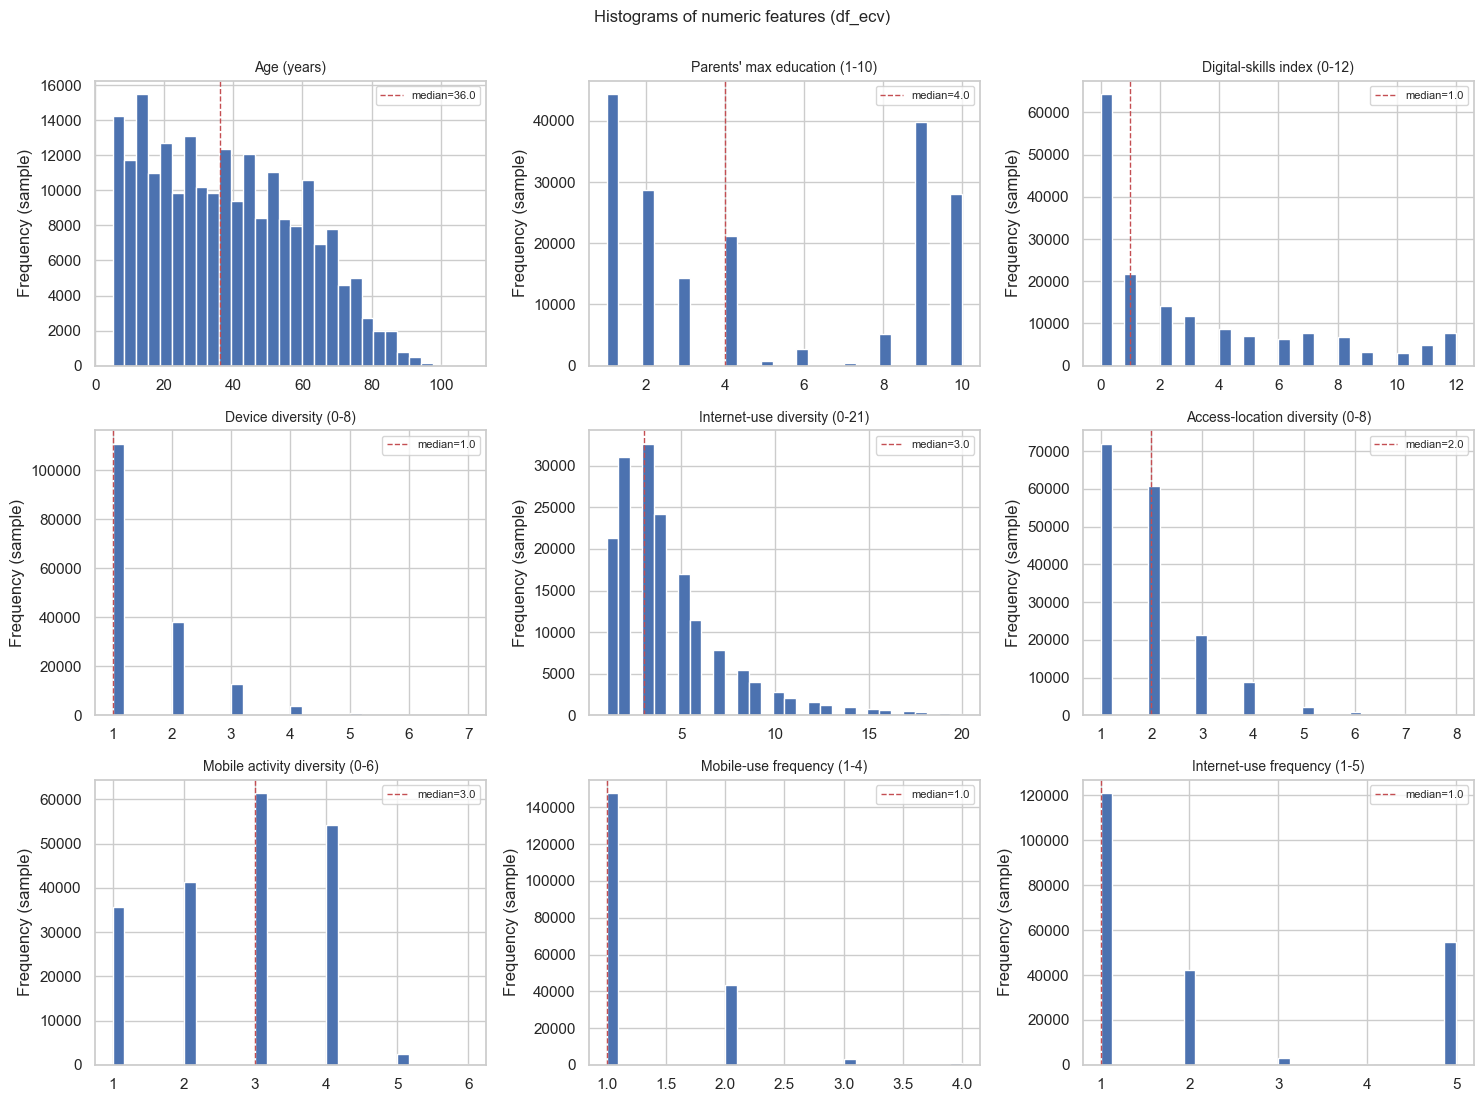

In [26]:
# Histograms of the key numeric features.
# 3x3 grid with the 9 numeric features of the consolidated matrix.
features_para_histograma = [
    ("hh_edad",                            "Age (years)"),
    ("hh_educacion_max_padres_codigo",     "Parents' max education (1-10)"),
    ("tic_indice_habilidades_digitales",   "Digital-skills index (0-12)"),
    ("tic_diversidad_dispositivos",        "Device diversity (0-8)"),
    ("tic_diversidad_usos_internet",       "Internet-use diversity (0-21)"),
    ("tic_diversidad_lugares_acceso",      "Access-location diversity (0-8)"),
    ("tic_diversidad_actividades_celular", "Mobile activity diversity (0-6)"),
    ("tic_frecuencia_uso_celular",         "Mobile-use frequency (1-4)"),
    ("tic_frecuencia_uso_internet",        "Internet-use frequency (1-5)"),
]

fig, ejes = plt.subplots(3, 3, figsize=(15, 11))
for ax, (columna, titulo) in zip(ejes.flat, features_para_histograma):
    serie = df_ecv[columna].dropna()
    ax.hist(serie, bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency (sample)")
    ax.axvline(serie.median(), color="#C44E52", linestyle="--", linewidth=1, label=f"median={serie.median():.1f}")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Histograms of numeric features (df_ecv)", fontsize=12, y=1.00)
fig.tight_layout()
plt.show()

- **Age**: relatively flat distribution between 5 and ~50 years with a progressive decline thereafter. Not a normal curve nor strongly skewed; it reflects a population pyramid with a broad base and middle. Median around 36 is consistent with that shape.
- **Parents' max education (1-10)**: strongly bimodal with peaks at the extremes — a large peak at level 1 (~45k, no studies / incomplete primary) and another tall peak at levels 9-10 (~40k + 28k, higher). Intermediate levels (5-8) are almost empty. This evidences a **generational educational polarization**: parents either have very little or very high schooling, with a sparse educational middle class.
- **Digital-skills index (0-12)**: strongly right-skewed with a dominant peak at 0 (~65k persons) and a small second group with skills 11-12. Not strictly bimodal — a decreasing distribution with a long tail that slightly rebounds at the end. Median at 1 confirms that most respondents report zero or one digital skill.
- **Device diversity (0-8)**: monotonically decreasing distribution, with an overwhelming peak at 1 (~110k) and an immediate drop. The vast majority uses **a single device** (smartphone).
- **Internet-use diversity (0-21)**: unimodal with right skew, peak at 2-3 uses and long tail. Median at 3 confirms limited instrumental use.
- **Access-location diversity (0-8)**: decreasing from 1 (peak ~72k) and 2 (~60k); almost nobody accesses from more than 3-4 locations.
- **Mobile activity diversity (0-6)**: roughly symmetric with peak at 3-4 (~60k + 54k). Those with a mobile use it for several things — a different pattern from digital skills (which was dominated by 0).
- **Mobile-use frequency (1-4)**: strongly concentrated at 1 (~145k, daily use). Categories 3-4 nearly nonexistent.
- **Internet-use frequency (1-5)**: clearly bimodal — main peak at 1 (~120k, daily) and a clear second peak at 5 (~55k, never).

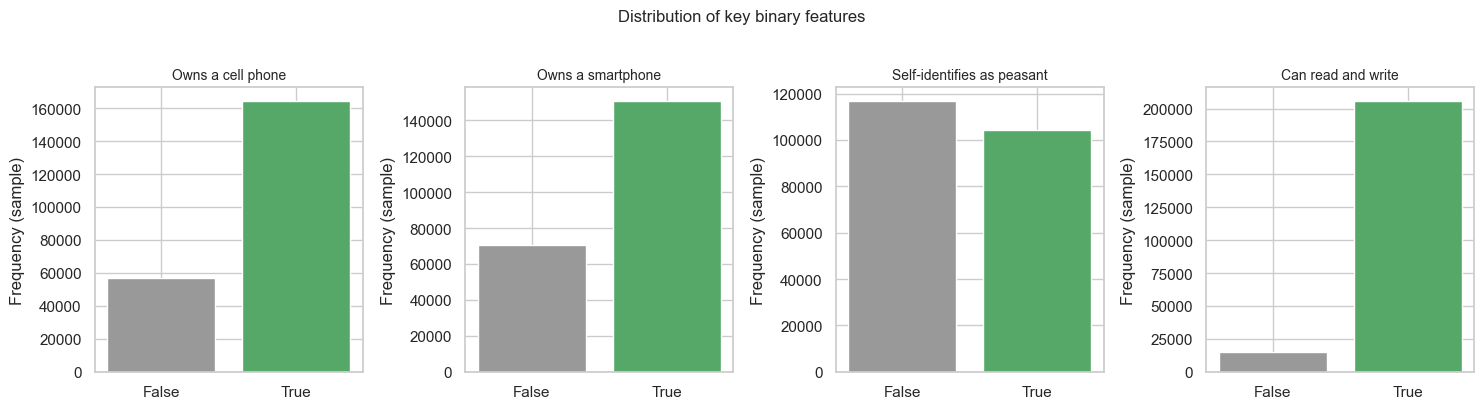

In [27]:
# Distribution of the binary tenure features.
features_booleanos_tenencia = [
    ("tic_tiene_celular_propio",  "Owns a cell phone"),
    ("tic_tiene_smartphone",      "Owns a smartphone"),
    ("hh_es_campesino",           "Self-identifies as peasant"),
    ("edu_alfabetizado",          "Can read and write"),
]

fig, ejes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (columna, titulo) in zip(ejes.flat, features_booleanos_tenencia):
    serie = df_ecv[columna].dropna()
    conteos = serie.value_counts().sort_index()
    proporciones = serie.value_counts(normalize=True).sort_index() * 100
    ax.bar([str(v) for v in conteos.index], conteos.values,
           color=["#999999", "#55A868"], edgecolor="white")
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel("Frequency (sample)")


fig.suptitle("Distribution of key binary features", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

- **Owns a cell phone**: ~165k True vs ~57k False (≈ 74% / 26%). Cell-phone ownership is majority but not universal: one in four respondents does not own a cell phone.
- **Owns a smartphone**: ~150k True vs ~70k False (≈ 68% / 32%). Smartphone penetration is high but lower than overall cell-phone ownership — a segment (~15k persons, the gap between the two bars) owns a conventional phone but no smartphone. This group is connected by phone but excluded from the digital ecosystem (apps, mobile internet, AI, banking).
- **Self-identifies as peasant**: ~117k False vs ~104k True (≈ 53% / 47%). The only balanced variable in the set — nearly half of respondents self-identify as peasants. This makes it statistically useful as a stratification variable (no minority class) and reflects the strong rurality / peasant identity in the ECV sample.
- **Can read and write**: ~205k True vs ~14k False (≈ 94% / 6%). Literacy is virtually universal. Due to extreme imbalance, this variable contributes little discriminative power in comparative analyses — the 6% illiterate group is small but socially relevant (likely overlapping with rural elderly without schooling).

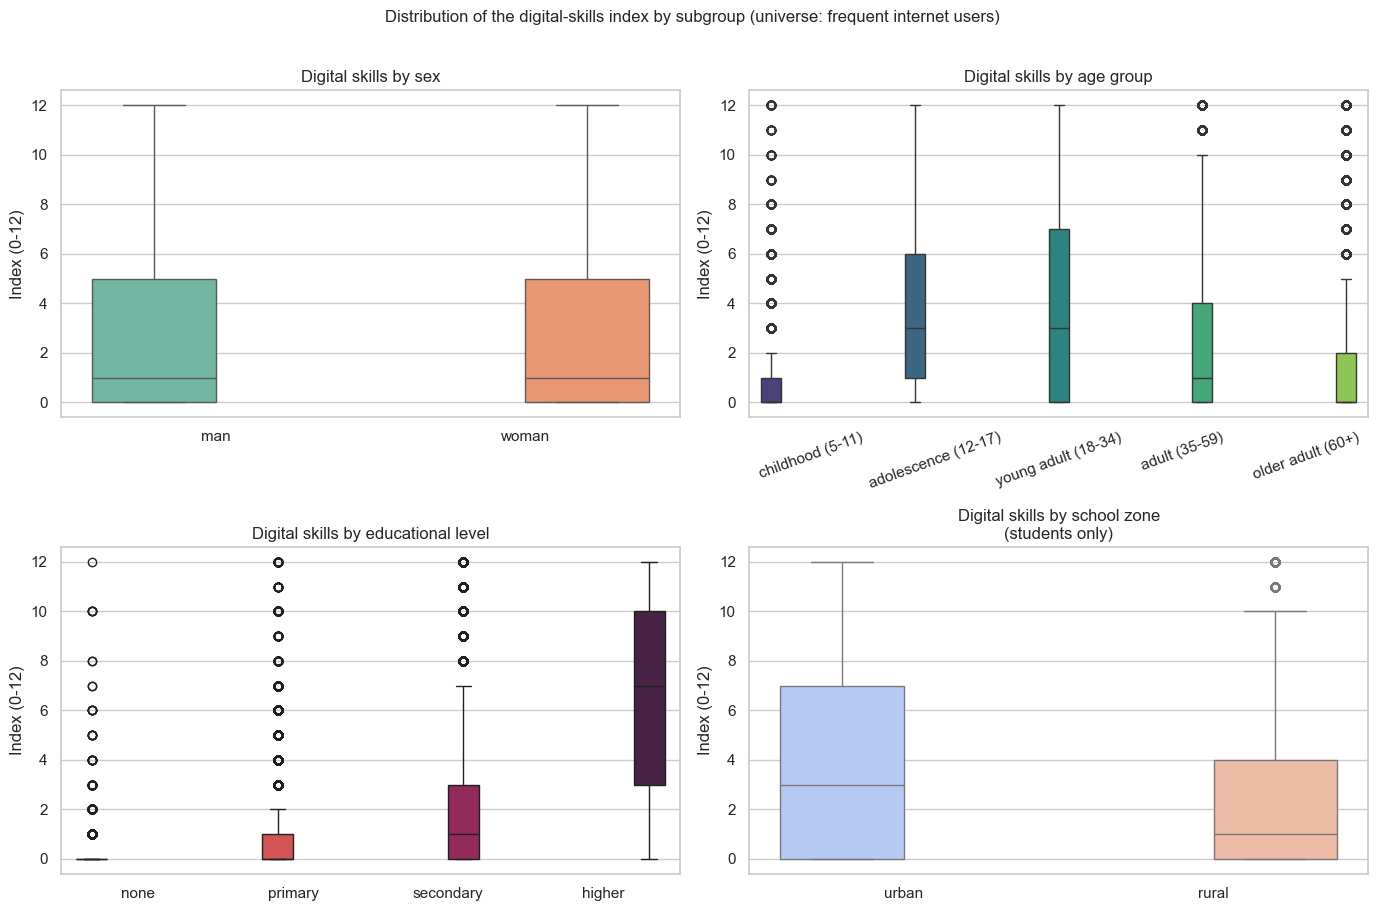

In [28]:
# Boxplots of the digital-skills index by four segmentation axes.
# Universe: frequent internet users (where the index is defined).
mascara_internauta_frecuente = df_ecv["tic_frecuencia_uso_internet"].isin([1, 2, 3])
df_internautas = df_ecv.loc[mascara_internauta_frecuente].copy()

fig, ejes = plt.subplots(2, 2, figsize=(14, 9))

# 1. By sex.
sns.boxplot(
    data=df_internautas, x="sexo", y="tic_indice_habilidades_digitales",
    ax=ejes[0, 0], hue="sexo", palette="Set2", legend=False,
)
ejes[0, 0].set_title("Digital skills by sex")
ejes[0, 0].set_xlabel("")
ejes[0, 0].set_ylabel("Index (0-12)")

# 2. By age group.
sns.boxplot(
    data=df_internautas, x="grupo_etario", y="tic_indice_habilidades_digitales",
    ax=ejes[0, 1], hue="grupo_etario", palette="viridis", legend=False,
)
ejes[0, 1].set_title("Digital skills by age group")
ejes[0, 1].set_xlabel("")
ejes[0, 1].set_ylabel("Index (0-12)")
ejes[0, 1].tick_params(axis="x", rotation=20)

# 3. By educational level.
sns.boxplot(
    data=df_internautas.dropna(subset=["edu_nivel_grupo"]),
    x="edu_nivel_grupo", y="tic_indice_habilidades_digitales",
    ax=ejes[1, 0], hue="edu_nivel_grupo", palette="rocket_r", legend=False,
    order=["none", "primary", "secondary", "higher"],
)
ejes[1, 0].set_title("Digital skills by educational level")
ejes[1, 0].set_xlabel("")
ejes[1, 0].set_ylabel("Index (0-12)")

# 4. By school zone (universe: students).
df_estudiantes_internautas = df_internautas.dropna(subset=["zona_establecimiento"])
sns.boxplot(
    data=df_estudiantes_internautas,
    x="zona_establecimiento", y="tic_indice_habilidades_digitales",
    ax=ejes[1, 1], hue="zona_establecimiento", palette="coolwarm", legend=False,
    order=["urban", "rural"],
)
ejes[1, 1].set_title("Digital skills by school zone\n(students only)")
ejes[1, 1].set_xlabel("")
ejes[1, 1].set_ylabel("Index (0-12)")

fig.suptitle("Distribution of the digital-skills index by subgroup (universe: frequent internet users)", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

- **By sex**: boxes for men and women are virtually identical (median = 1, Q3 = 5, same range). The **gender gap in digital skills is negligible** in this universe — sex is not a relevant inequality axis once frequent internet use is controlled for.

- **By age group**: childhood (5-11) is concentrated at 0-1 skills; adolescence (12-17) and young adulthood (18-34) reach the highest values (median = 3, Q3 between 6 and 7); adulthood (35-59) drops to median = 1 (Q3 = 4); older adulthood (60+) falls to median = 0 (Q3 = 2).

- **By educational level**: the jump between secondary and higher is large (median 1 → 7, Q3 3 → 10). Formal education is **the strongest predictor** of digital skills in the sample; outliers at low levels suggest minority self-learning.

- **By school zone (students only)**: urban students (median = 3, Q3 = 7) clearly outperform rural students (median = 1, Q3 = 4). The **urban-rural gap persists even within the active student population**, indicating that school attendance alone does not compensate for infrastructure / digital-context territorial differences.

### 4.2. Two-sample independent t-test (urban vs rural)

We compare the digital-skills index between urban and rural students using a two-sample independent t-test (`scipy.stats.ttest_ind`). This is the first formal hypothesis test of the analysis.

In [29]:
# Universe: student internet users with reported zone.
mask = df_ecv["zona_establecimiento"].notna() & df_ecv["tic_frecuencia_uso_internet"].isin([1, 2, 3])
estudiantes_internautas_urbanos = mask & (df_ecv["zona_establecimiento"] == "urban")
estudiantes_internautas_rurales = mask & (df_ecv["zona_establecimiento"] == "rural")

urbana = df_ecv.loc[estudiantes_internautas_urbanos, "tic_indice_habilidades_digitales"].dropna()
rural  = df_ecv.loc[estudiantes_internautas_rurales,  "tic_indice_habilidades_digitales"].dropna()

t, p = stats.ttest_ind(urbana, rural, equal_var=False)

print(f"Urban: n={len(urbana):,}, mean={urbana.mean():.2f}")
print(f"Rural: n={len(rural):,}, mean={rural.mean():.2f}")
print(f"Mean difference: {urbana.mean() - rural.mean():+.2f}")
print(f"t = {t:.2f},  p-value = {p:.4e}")
print("→ " + ("Reject H0: means differ significantly." if p < 0.05 else "Fail to reject H0."))

Urban: n=27,991, mean=4.00
Rural: n=12,120, mean=2.24
Mean difference: +1.76
t = 51.73,  p-value = 0.0000e+00
→ Reject H0: means differ significantly.


Comparing only students who use the internet frequently, those in **urban areas** average **4.0** digital skills versus **2.2** in **rural** areas — a difference of **1.8 points** on a 0–12 scale, practically **double**. This difference is **real and not due to chance**. The important point is that, even when comparing young people who already use the internet often, the gap persists: it is not just about "having or not having internet", but about **environmental differences** (better schools, better connectivity, better resources at home, better teacher training) that favor those who study in cities.

### 4.3. One-way ANOVA by educational level

A one-way ANOVA (`scipy.stats.f_oneway`) is applied to compare the digital-skills index across the **4 educational-level groups** (`none`, `primary`, `secondary`, `higher`). It is the natural statistical test for more than two groups and complements the previous t-tests (which compare only pairs).

In [30]:
# ANOVA of tic_indice_habilidades_digitales by edu_nivel_grupo (4 groups).
# http://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html

niveles = ["none", "primary", "secondary", "higher"]
grupos = [df_ecv.loc[df_ecv["edu_nivel_grupo"] == g, "tic_indice_habilidades_digitales"].dropna()
          for g in niveles]

F, p = stats.f_oneway(*grupos)

# eta^2 = variance explained by the factor / total variance.
todos = pd.concat(grupos)
eta_cuadrado = 1 - sum(g.var(ddof=0) * len(g) for g in grupos) / (todos.var(ddof=0) * len(todos))

print(pd.Series({g: s.mean() for g, s in zip(niveles, grupos)}).round(2))
print(f"\nF={F:.1f}  p={p:.2e}  eta^2={eta_cuadrado:.3f}")

none         0.37
primary      0.68
secondary    2.25
higher       6.38
dtype: float64

F=20942.9  p=0.00e+00  eta^2=0.336


The analysis shows that educational levels have very different average digital-skill scores: people with no schooling reach barely 0.4 points, primary 0.7, secondary 2.3 and higher education 6.4 (on a 0–10 scale). **The more education, the more digital skills**, and the gap between secondary and higher is the largest. The difference is real and not due to chance, and educational attainment alone explains roughly **one third (34%)** of the variation in digital skills. In other words: **education is the factor that weighs most** in explaining who handles digital tools well — more than sex or school zone.

## 5. Data separability

### 5.1 · Defining the unsupervised problem

After evaluating the limitations of supervised classification — chiefly the lack of labels — Section 5 is tackled via **unsupervised clustering** over the ICT space. Digital-behavior typologies are discovered and then externally validated with **ARI** against socio-educational labels.

**The 9 ICT features used for clustering**

| Feature | Range |
|---|---|
| `tic_indice_habilidades_digitales` | 0–12 |
| `tic_diversidad_dispositivos` | 0–8 |
| `tic_diversidad_usos_internet` | 0–21 |
| `tic_diversidad_lugares_acceso` | 0–8 |
| `tic_diversidad_actividades_celular` | 0–6 |
| `tic_uso_internet_invertido` | 0–4 |
| `tic_uso_celular_invertido` | 0–3 |
| `tic_tiene_celular_propio` | bool → int |
| `tic_tiene_smartphone` | bool → int |

**Why we invert the frequencies.** In the DANE questionnaire `1 = daily` and `5 = never`. For Euclidean clustering in the scaled space, it is convenient that **all features point in the same semantic direction** (higher value = greater digital adoption).

**External labels for ARI validation**

| Label | Question answered by ARI |
|---|---|
| `edu_nivel_grupo` | Do clusters reproduce the educational gradient? |
| `hh_educacion_max_padres_grupo` | Do they reproduce intergenerational cultural capital? |
| `zona_establecimiento` | Do they reproduce the urban/rural gap (students subset)? |
| `hh_etnia_grupo` | Is there ethnic differentiation? |
| `hh_es_campesino` | Do they reproduce the territorial/cultural peasant dimension? |
| `hh_sexo` | Is there a gender gap? |
| `grupo_etario` | Is there a generational gap? |

In [31]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

SEMILLA_KMEANS: int = 42
N_INIT_KMEANS: int = 10  # number of random initializations before keeping the best

In [32]:
# Build the clustering-universe DataFrame.
# Universe: frequent internet users (P1084 in {1, 2, 3}) with defined skills index.
mascara_universo_clustering = (
    df_ecv["tic_frecuencia_uso_internet"].isin([1, 2, 3])
    & df_ecv["tic_indice_habilidades_digitales"].notna()
)

df_clustering = df_ecv.loc[mascara_universo_clustering].copy()
print(f"Clustering universe (frequent internet users): {len(df_clustering):,} persons")

# Build inverted versions of the frequencies so that higher = more use.
df_clustering["tic_uso_internet_invertido"] = 5 - df_clustering["tic_frecuencia_uso_internet"]
df_clustering["tic_uso_celular_invertido"]  = 4 - df_clustering["tic_frecuencia_uso_celular"]

features_clustering = [
    "tic_indice_habilidades_digitales",
    "tic_diversidad_dispositivos",
    "tic_diversidad_usos_internet",
    "tic_diversidad_lugares_acceso",
    "tic_diversidad_actividades_celular",
    "tic_uso_internet_invertido",
    "tic_uso_celular_invertido",
]

Clustering universe (frequent internet users): 166,015 persons


In [33]:
# Imputation, scaling and construction of the X matrix for clustering.
# Strategy: impute NaN with the feature median (minimal impact given small NaN %),
# then standardize with StandardScaler. K-means is scale-sensitive and rejects NaN.

# Median imputation (in-place on df_clustering).
for feature in features_clustering:
    if df_clustering[feature].isna().any():
        valor_mediana = df_clustering[feature].median()
        df_clustering[feature] = df_clustering[feature].fillna(valor_mediana)

# Build the feature matrix and scale it.
matriz_features_brutas    = df_clustering[features_clustering].to_numpy()
escalador_features        = StandardScaler()
matriz_features_escaladas = escalador_features.fit_transform(matriz_features_brutas)

print(f"Scaled feature matrix: {matriz_features_escaladas.shape}  (rows x features)")

Scaled feature matrix: (166015, 7)  (rows x features)


In [34]:
# Dictionary of external labels for ARI validation.
labels_externos_para_ari: dict[str, pd.Series] = {
    "edu_nivel_grupo":               df_clustering["edu_nivel_grupo"],
    "hh_educacion_max_padres_grupo": df_clustering["hh_educacion_max_padres_grupo"],
    "zona_establecimiento":          df_clustering["zona_establecimiento"],
    "hh_etnia_grupo":                df_clustering["hh_etnia_grupo"],
    "hh_es_campesino":               df_clustering["hh_es_campesino"],
    "hh_sexo":                       df_clustering["hh_sexo"],
    "grupo_etario":                  df_clustering["grupo_etario"],
    "tic_tiene_smartphone":          df_clustering["tic_tiene_smartphone"],
    "tic_tiene_celular_propio":      df_clustering["tic_tiene_celular_propio"],
}

In [35]:
# Build the feature matrix and scale it.
matriz_features_brutas = df_clustering[features_clustering].to_numpy()
escalador_features = StandardScaler()
matriz_features_escaladas = escalador_features.fit_transform(matriz_features_brutas)

### 5.2 · Selecting the optimal number of clusters

| Metric | Interpretation |
|---|---|
| **Inertia** | How compact the clusters are internally. |
| **Silhouette score** | Cohesion vs separation. Range [−1, 1], **higher = better**. Insensitive to `k` by construction. |
| **Davies–Bouldin Index (DBI)** | Ratio of within-cluster scatter to between-cluster distance. **Lower = better**. |

In [36]:
# To speed up silhouette on 166k rows, it is computed on a reproducible sub-sample.
TAMANO_SUBMUESTRA_SILHOUETTE = 10_000

def evaluar_kmeans_para_k(X, k, semilla=SEMILLA_KMEANS, n_init=N_INIT_KMEANS, tamano_submuestra_silhouette=TAMANO_SUBMUESTRA_SILHOUETTE):
    """Train k-means with `k` clusters on `X` and return the 3 evaluation metrics."""
    modelo_kmeans = KMeans(n_clusters=k, n_init=n_init, random_state=semilla)
    etiquetas_clusters = modelo_kmeans.fit_predict(X)

    # Silhouette: sub-sample for speed. Reproducibility fixed via random_state.
    silhouette = silhouette_score(
        X, etiquetas_clusters,
        sample_size=tamano_submuestra_silhouette,
        random_state=semilla,
    )

    # Davies-Bouldin over the whole sample.
    dbi = davies_bouldin_score(X, etiquetas_clusters)

    return {
        "k":              k,
        "inercia":        modelo_kmeans.inertia_,
        "silhouette":     silhouette,
        "davies_bouldin": dbi,
        "etiquetas":      etiquetas_clusters,
        "modelo":         modelo_kmeans,
    }

In [37]:
# Sweep of k in {2..8}.
valores_k_a_probar = list(range(2, 9))
resultados_barrido_k = {}

for k in valores_k_a_probar:
    print(f"Training k-means with k={k}...")
    resultado = evaluar_kmeans_para_k(matriz_features_escaladas, k)
    resultados_barrido_k[k] = resultado
    print(f"inertia={resultado['inercia']:>10,.0f}  silhouette={resultado['silhouette']:.4f}  DBI={resultado['davies_bouldin']:.4f}")

# Summary table.
tabla_metricas_clustering = pd.DataFrame([
    {
        "k":              r["k"],
        "inercia":        round(r["inercia"], 0),
        "silhouette":     round(r["silhouette"], 4),
        "davies_bouldin": round(r["davies_bouldin"], 4),
    }
    for r in resultados_barrido_k.values()
])
print("\nSummary table")
print(tabla_metricas_clustering)

Training k-means with k=2...
inertia=   841,025  silhouette=0.2930  DBI=1.4061
Training k-means with k=3...
inertia=   634,133  silhouette=0.3184  DBI=1.2139
Training k-means with k=4...
inertia=   565,469  silhouette=0.2184  DBI=1.4859
Training k-means with k=5...
inertia=   509,677  silhouette=0.2341  DBI=1.3902
Training k-means with k=6...
inertia=   463,013  silhouette=0.2325  DBI=1.3870
Training k-means with k=7...
inertia=   425,659  silhouette=0.2484  DBI=1.2945
Training k-means with k=8...
inertia=   403,738  silhouette=0.2500  DBI=1.3423

Summary table
   k   inercia  silhouette  davies_bouldin
0  2  841025.0      0.2930          1.4061
1  3  634133.0      0.3184          1.2139
2  4  565469.0      0.2184          1.4859
3  5  509677.0      0.2341          1.3902
4  6  463013.0      0.2325          1.3870
5  7  425659.0      0.2484          1.2945
6  8  403738.0      0.2500          1.3423


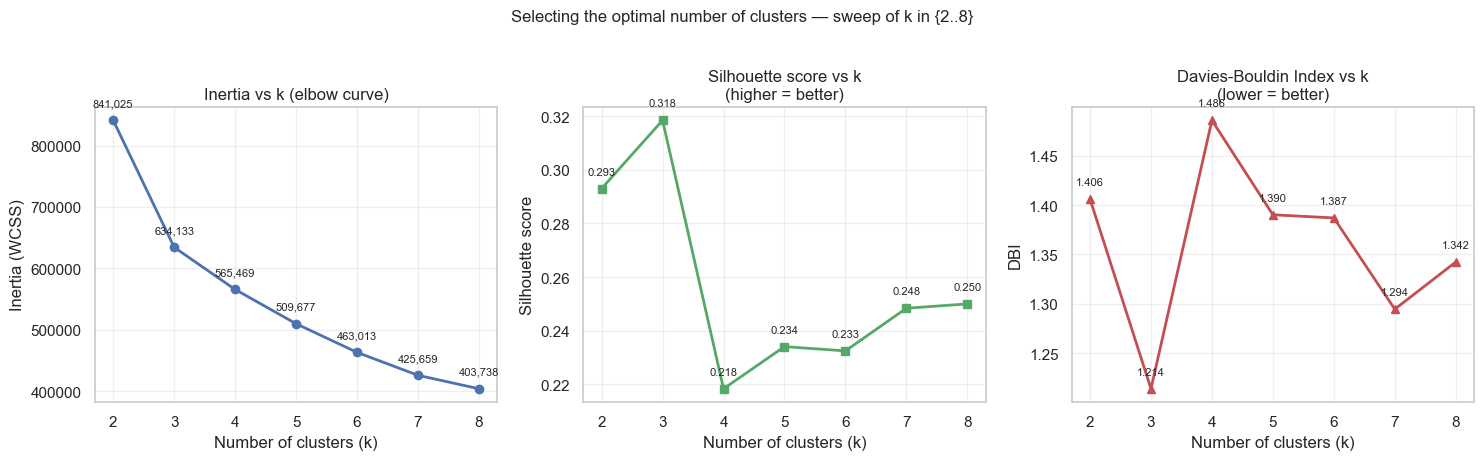

In [38]:
# Visualization of the 3 metrics vs k.
metricas = [
    ("inercia",        "Inertia vs k (elbow curve)",              "Inertia (WCSS)",   "o", "#4C72B0", "{:,.0f}"),
    ("silhouette",     "Silhouette score vs k\n(higher = better)", "Silhouette score", "s", "#55A868", "{:.3f}"),
    ("davies_bouldin", "Davies-Bouldin Index vs k\n(lower = better)", "DBI",            "^", "#C44E52", "{:.3f}"),
]

fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))
k = tabla_metricas_clustering["k"]

for ax, (col, titulo, ylabel, marker, color, fmt) in zip(ejes, metricas):
    y = tabla_metricas_clustering[col]
    ax.plot(k, y, marker=marker, color=color, linewidth=2)
    ax.set(title=titulo, xlabel="Number of clusters (k)", ylabel=ylabel)
    ax.grid(alpha=0.3)
    for xi, yi in zip(k, y):
        ax.annotate(fmt.format(yi), (xi, yi), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=8)

fig.suptitle("Selecting the optimal number of clusters — sweep of k in {2..8}", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

In [39]:
idx_max_silhouette = tabla_metricas_clustering["silhouette"].idxmax()
K_OPTIMO = int(tabla_metricas_clustering.loc[idx_max_silhouette, "k"])
print(f"K_OPTIMO selected = {K_OPTIMO}")

K_OPTIMO selected = 3


In [40]:
# Training the final k-means model with K_OPTIMO.
modelo_final_kmeans = KMeans(n_clusters=K_OPTIMO, n_init=N_INIT_KMEANS, random_state=SEMILLA_KMEANS)
df_clustering["cluster"] = modelo_final_kmeans.fit_predict(matriz_features_escaladas)

# Sample and population size of each cluster.
print(f"Cluster assignment (k = {K_OPTIMO}):\n")
filas_tamanos = []
for cluster_id in range(K_OPTIMO):
    mascara = df_clustering["cluster"] == cluster_id
    n_muestral = int(mascara.sum())
    n_poblacional = float(df_clustering.loc[mascara, "FEX_C"].sum())
    filas_tamanos.append({
        "cluster": cluster_id,
        "n_sample":          n_muestral,
        "% sample":          round(n_muestral / len(df_clustering) * 100, 2),
        "n_population":      round(n_poblacional, 0),
        "% population":      round(n_poblacional / df_clustering["FEX_C"].sum() * 100, 2),
    })
tabla_tamanos_clusters = pd.DataFrame(filas_tamanos)
print(tabla_tamanos_clusters.to_string(index=False))

Cluster assignment (k = 3):

 cluster  n_sample  % sample  n_population  % population
       0     38142     22.98    13493705.0         32.79
       1     96781     58.30    21943339.0         53.32
       2     31092     18.73     5715048.0         13.89


The final k-means assigns the 166,015 persons to three clusters of unequal but all substantive sizes: **cluster 1 is dominant** with 58.3% of the sample (53.3% of the population, ≈ 21.9 million people), followed by **cluster 0** with 23.0% of the sample (32.8% of the population, ≈ 13.5 million) and **cluster 2** with 18.7% of the sample (13.9% of the population, ≈ 5.7 million). No cluster is residual (< 5%), confirming that the three represent real digital typologies.

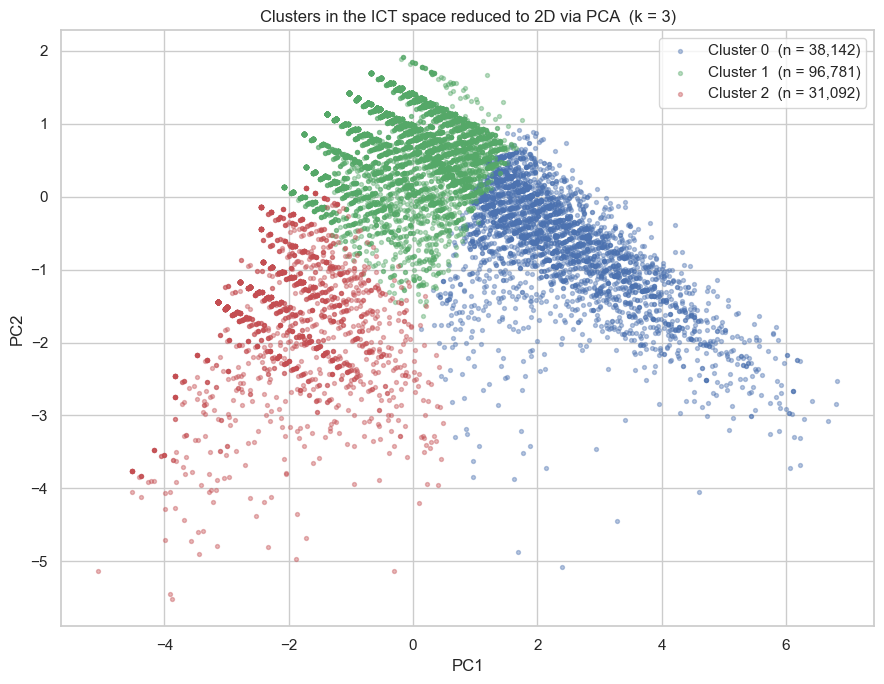

In [41]:
# 2D PCA visualization colored by cluster.
# Reduce the ICT space from 7D to 2D to visualize the structure.
pca_2d = PCA(n_components=2, random_state=SEMILLA_KMEANS)
matriz_features_pca = pca_2d.fit_transform(matriz_features_escaladas)

# Random sub-sampling so the scatter remains legible (166k points saturate the figure).
SEMILLA_PLOT = 7
np.random.seed(SEMILLA_PLOT)
indices_submuestra_plot = np.random.choice(len(matriz_features_pca), size=15_000, replace=False)

fig, ax = plt.subplots(figsize=(9, 7))
paleta_clusters = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"][:K_OPTIMO]
for cluster_id in range(K_OPTIMO):
    mascara_cluster = df_clustering["cluster"].iloc[indices_submuestra_plot] == cluster_id
    indices_cluster = indices_submuestra_plot[mascara_cluster.to_numpy()]
    n_cluster = (df_clustering["cluster"] == cluster_id).sum()
    ax.scatter(
        matriz_features_pca[indices_cluster, 0],
        matriz_features_pca[indices_cluster, 1],
        s=8, alpha=0.4,
        color=paleta_clusters[cluster_id],
        label=f"Cluster {cluster_id}  (n = {n_cluster:,})",
    )

ax.set_title(f"Clusters in the ICT space reduced to 2D via PCA  (k = {K_OPTIMO})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

The 2D projection shows that the three clusters occupy differentiated regions with soft boundaries — not perfectly separated, consistent with a silhouette of 0.318 — and visually validate the choice of k = 3: **PC1** sorts a clear "digital intensity" gradient from left (cluster 2 red, PC1 < 0) through the center (cluster 1 green) to the right (cluster 0 blue, PC1 > 0), suggesting that the dominant dimension of the ICT space is an adoption continuum running from excluded to advanced users; **PC2** adds a second dimension that systematically places the green cluster above the others, indicating that the intermediate cluster is not a simple "midpoint" but a qualitatively distinct typology (likely intensive mobile users with limited skills); and the absence of phantom clusters or extreme outliers confirms that a fourth cluster would have artificially split one of these cohesive groups. The plot geometry thus supports the substantive narrative of three real digital typologies — excluded, basic/typical users and advanced users — coherent with the observed population sizes.

### 5.3 · External validation with the Adjusted Rand Index (ARI) and final interpretation

The **Adjusted Rand Index** compares two partitions of the same dataset: the cluster assignment produced by k-means and a known label (e.g. `edu_nivel_grupo`). It measures the fraction of pairs of points that agree across both partitions, adjusted for chance.

| Range | Interpretation |
|---|---|
| ARI = **1.0** | Identical partitions — clusters perfectly reproduce the label. |
| ARI ≈ **0.0** | No relation beyond chance. |
| ARI **negative** | Less consistent than chance. |
| ARI ≈ **0.1–0.3** | Moderate agreement. |
| ARI ≈ **0.5+** | Strong agreement. |

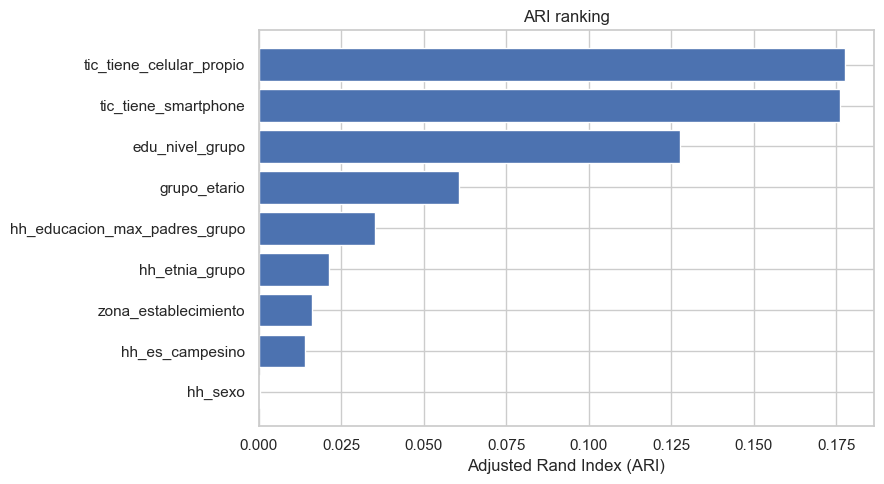

In [42]:
# ARI against each external label.
# For each label, ARI is computed on the subset where the label is not NaN.
# This means different labels have different effective n.

filas_resultados_ari = []
for nombre_label, serie_label in labels_externos_para_ari.items():
    mascara_label_valido = serie_label.notna()
    n_validos = int(mascara_label_valido.sum())
    if n_validos == 0:
        continue
    etiquetas_clusters_subset = df_clustering.loc[mascara_label_valido, "cluster"].to_numpy()
    valores_label_subset = serie_label.loc[mascara_label_valido].astype(str).to_numpy()
    valor_ari = adjusted_rand_score(valores_label_subset, etiquetas_clusters_subset)
    filas_resultados_ari.append({
        "external_label":  nombre_label,
        "n_valid":         n_validos,
        "n_categories":    int(serie_label.dropna().nunique()),
        "ari":             round(valor_ari, 4),
    })

tabla_ari = (
    pd.DataFrame(filas_resultados_ari)
    .sort_values("ari", ascending=False)
    .reset_index(drop=True)
)

# Visualization of the ARI ranking.
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tabla_ari["external_label"], tabla_ari["ari"], edgecolor="white")
ax.set_xlabel("Adjusted Rand Index (ARI)")
ax.set_title("ARI ranking")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The ARI ranking reveals a highly informative hierarchy of which socio-educational labels best correspond to the identified digital clusters: at the top are tic_tiene_celular_propio (≈ 0.178) and tic_tiene_smartphone (≈ 0.176), practically tied, which is to be expected—these are binary ICT features highly correlated with those used in the clustering—; the truly substantive finding is that edu_nivel_grupo ranks third (≈ 0.128), a moderate but notable value considering that educational level was not included in the clustering and yet still manages to partially reproduce the discovered digital structure, empirically confirming that formal education is the main socioeconomic driver of the digital divide. In a second tier appear age group (≈ 0.06) and parental education (≈ 0.035), with material but modest effects—age shapes ICT use less than is commonly assumed, and the educational legacy of parents is overshadowed by one’s own education—; ethnicity, school location, and self-identification as rural fall to the 0.01–0.02 range (nearly negligible effects), and sex falls to ≈ 0, confirming what the t-test and boxplots already showed: gender does not shape the digital divide in Colombia

## Conclusions

1.  There is a substantial urban-rural gap among students who use the internet (t-test: Δμ = +1.76 points, with nearly twice the level of skills in urban areas); therefore, educational level and geographic location account for the gap, whereas gender does not. This is confirmed by the ANOVA. The ANOVA confirms that higher education correlates with greater digital skills: the means rise from 0.37 (no education) to 0.68 (primary), 2.25 (secondary), and 6.38 (higher education), with the sharpest increase occurring between secondary and higher education. The difference is real and not a product of chance (F = 20,942, p ≈ 0), and educational level alone explains nearly 34% of the variation in digital skills—a large effect. Formal education is, therefore, the most significant factor in explaining the digital divide in Colombia.

2. **The ICT space naturally organizes into three digital typologies**. The three internal clustering metrics (inertia, silhouette, and Davies-Bouldin) converge on k=3. The resulting clusters correspond, in substantive terms, to **digitally excluded** (≈ 33% of the population), **basic/mobile users** (≈ 53%), and **advanced users** (≈ 14%).

3. **External validation with ARI confirms the substantive interpretation.** Even though it was not included in the clustering, educational level partially replicates the discovered digital structure (ARI ≈ 0.13), age group does so moderately (≈ 0.06), and gender yields a value of zero (≈ 0). 
